In [1]:
# import subprocess
# import sys

# try:
#     from ultralytics import YOLO
# except ModuleNotFoundError : 
#     print("ultralytics가 설치되지 않음")

#     try:
#         subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics', 'opencv-python'])

#     except subprocess.CalledProcessError as e:
#         raise SystemExit(f"ultralytics 설치 실패 : {e}")
    
# from ultralytics import YOLO

!pip install ultralytics opencv-python

In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.51 🚀 Python-3.10.20 torch-1.13.1+cu117 CUDA:0 (NVIDIA GeForce MX250, 1994MiB)
Setup complete ✅ (8 CPUs, 15.4 GB RAM, 87.9/97.9 GB disk)


In [3]:
# YOLO11 모델로 이미지 감지
from ultralytics import YOLO

model = YOLO('yolo11n.pt')
print(model.names, len(model.names))




{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [4]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CUDA 사용 불가")

import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

x = torch.rand(3, 3).cuda()
y = x @ x
print(y)

1.13.1+cu117
True
NVIDIA GeForce MX250
1.13.1+cu117
11.7
True
NVIDIA GeForce MX250
tensor([[0.2442, 0.2771, 0.5041],
        [0.5661, 0.8025, 0.6082],
        [0.2516, 0.3868, 0.3580]], device='cuda:0')


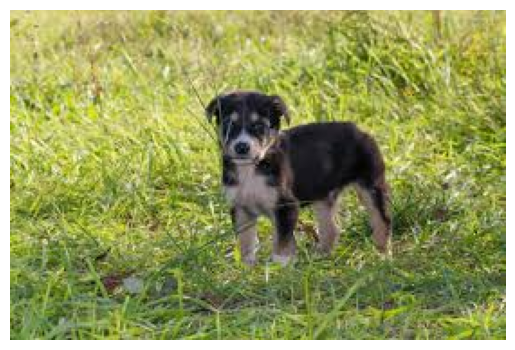


0: 448x640 1 dog, 15.0ms
Speed: 11.3ms preprocess, 15.0ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)
(183, 275)
image.shape :  (183, 275, 3)
image[0, 0] :  [215 206 151]


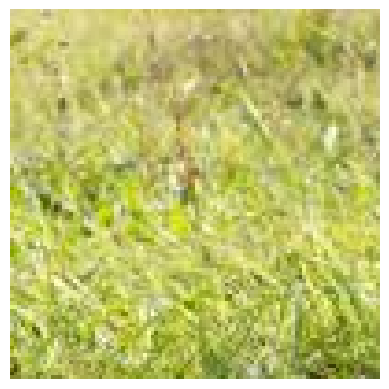

In [7]:
# 이미지 로딩 후 감지
from PIL import Image
import matplotlib.pyplot as plt
import sys

image_path = "./yolo_imgs/street_dog.jpg"

try:
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
except Exception as e:
    print("load err : ", e)
    sys.exit()

# 객체 감지
import cv2
import numpy as np

try:
    results = model(img)
    print(results[0].orig_shape)

except Exception as e:
    print("detect err : ", e)
    sys.exit()

image = np.array(img)
print("image.shape : ", image.shape)
print("image[0, 0] : ", image[0,0])

# 이미지 영역 자르기
cropped = image[:100, :100]
plt.imshow(cropped)
plt.axis("off")
plt.show()

107 44 212 142
dog
box.conf[0] :  tensor(0.9242, device='cuda:0')
신뢰도 :  0.924182653427124
dog detected :  True


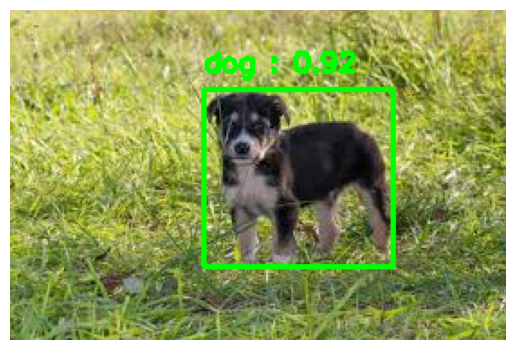

개가 보입니다. (엄격한 confidence 기준 0.4 이상 만족)


True

In [8]:
# dog 이미지에 박스 채우기
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

dog_detected = False            # dog 감지 여부 판단용 함수

'''
* YOLO confidence 계산 원리 *
YOLO는 한 개의 박스(box)에 대해 크게 두 가지를 예측한다:
1) Objectness Score :  이 박스 안에 “물체가 있을 확률”.  범위: 0 ~ 1
   예: 0.9 → 90% 확률로 뭔가 물체가 있음
2) Class Probability Distribution :  그 물체가 어떤 클래스인지의 확률 분포
   softmax나 sigmoid를 통해 각 클래스별 확률을 출력
   예: {dog: 0.8, cat: 0.15, person: 0.05}

최종 Confidence 수식 
 YOLO는 특정 클래스 c에 대해 Confidence(box, c) = P(object) × P(class=c ∣ object)
 즉, 물체가 있음 확률 × 그 물체가 특정 클래스일 확률로 계산한다.

예) Objectness = 0.9, Class probabilities = {dog: 0.8, cat: 0.15, person: 0.05}
     dog 클래스의 confidence는 0.9×0.8=0.72
     따라서 출력은  dog: 0.72,  cat: 0.135,  person: 0.045

훈련 과정에서
  - 정답(GT) 박스와 예측 박스를 IoU로 비교해서 Positive / Negative 결정
  - Loss 함수에 objectness loss + classification loss + localization loss가 모두 들어감
  - objectness는 IoU를 기반으로 라벨링되므로, 결국 학습하면서 “confidence가 IoU에 비례하도록” 학습됨

간단히 말해 YOLO의 confidence = Objectness × Class probability로 계산한다.
  - objectness → 이 위치에 물체가 있을 가능성
  - class prob → 그것이 특정 클래스일 가능성
  이 두 개를 곱해 최종 confidence가 출력됨
'''

for result in results:
    try:
        # 감지된 객체들의 바운딩 박스 리스트
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            print(x1, y1, x2, y2)

            label = result.names[int(box.cls[0])]                           # 감지된 객체 클래스 이름 얻기
            print(label)

            print("box.conf[0] : ", box.conf[0])
            confidence = box.conf[0].item()                                 # 신뢰도(바운딩 박스 안에 해당 클래스가 실제로 있을 확률값)
            print("신뢰도 : ",confidence)

            if label == "dog" and confidence > 0.4:                         # 기준 cofidence 값은 실제로는 0.25~0.3 설정. (엄격하게 설정 할 경우, 0.4 설정)
                dog_detected = True

            # 바운딩 박스 그리기
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)        # 색깔은 초록색(0, 255, 0), 선 굵기 = 2.0

            # 신뢰도 text로 표시
            cv2.putText(image, f"{label} : {confidence:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)     # 글씨체 : FONT_HERSHEY_SIMPLEX, 글씨 크기 : .5, 글씨 색깔 : 초록색(0, 255, 0), 글씨 두께 : 2 

    except Exception as e:
        print("process err : ", e)
    
print("dog detected : ", dog_detected)


plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

if label == "dog" and confidence > 0.4:
    print("개가 보입니다. (엄격한 confidence 기준 0.4 이상 만족)")

# 감지 결과를 파일로 저장
cv2.imwrite("yolo1out.jpg", image)

# colab에서 저장한 이미지 다운로드 할 경우 (colab에서만 가능)
# from google.colab import files
# files.download("yolo1out.jpg")